In [2]:
from vmc_2024_02_28 import output_dir, get_config, get_lattice, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

Running dilated_nns_xors.py


In [4]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
)

/gpfs/home1/ishchurov/frustrations-eda/misc_utils.py:204: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dataframes).reset_index(drop=True)


In [8]:
df.query('task_id == 12')['overlap']

72610    0.315383
72611    0.331607
72612    0.354164
72613    0.385523
72614    0.426786
           ...   
81917    0.993357
81918    0.993505
81919    0.993407
81920    0.993058
81921    0.992889
Name: overlap, Length: 9312, dtype: float64

In [11]:
df.columns

Index(['n_samples', 'lr', 'momentum', 'batch_size', 'sign_noise',
       'weight_decay', 'annealing_steps', 'initial_temp', 'max_iter',
       'sampling_mode', 'lattice', 'J2', 'use_symmetries', 'spin_inversion',
       'eval_set_max_size', 'save_predictions', 'device', 'random_seed',
       'force_numpy_sampling', 'log_prob_fn', 'n_hidden', 'hidden_layers',
       'overlap', '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'temp',
       'start_timestamp', 'task_id', 'prob_to_float64', 'dilations',
       'hidden_channels', 'kernel_size'],
      dtype='object')

In [13]:
df.groupby('kernel_size')['overlap']

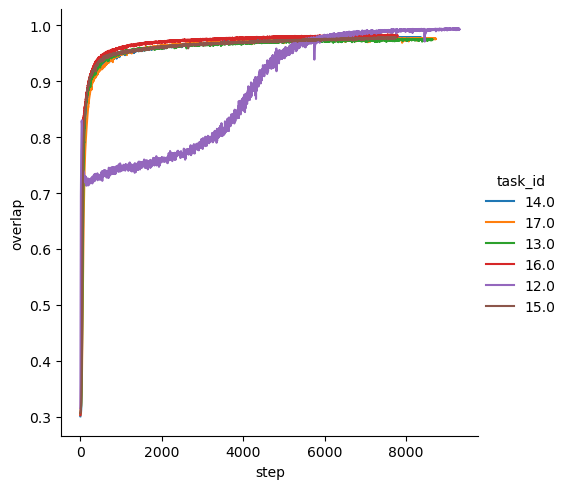

In [20]:
sns.relplot(
    df.query("task_id >= 12")
    .pipe(column_to(str, "task_id"))
    .assign(overlap_smooth=lambda df: df['overlap'].rolling(window=100).mean()),
    x="step",
    y="overlap",
    kind="line",
    hue="task_id",
   # style='task_id',
)#.set(yscale="log")

In [6]:
df.columns

Index(['n_samples', 'lr', 'momentum', 'batch_size', 'sign_noise',
       'weight_decay', 'annealing_steps', 'initial_temp', 'max_iter',
       'sampling_mode', 'lattice', 'J2', 'use_symmetries', 'spin_inversion',
       'eval_set_max_size', 'save_predictions', 'device', 'random_seed',
       'force_numpy_sampling', 'log_prob_fn', 'n_hidden', 'hidden_layers',
       'overlap', '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'temp',
       'start_timestamp', 'task_id', 'prob_to_float64', 'dilations',
       'hidden_channels', 'kernel_size'],
      dtype='object')

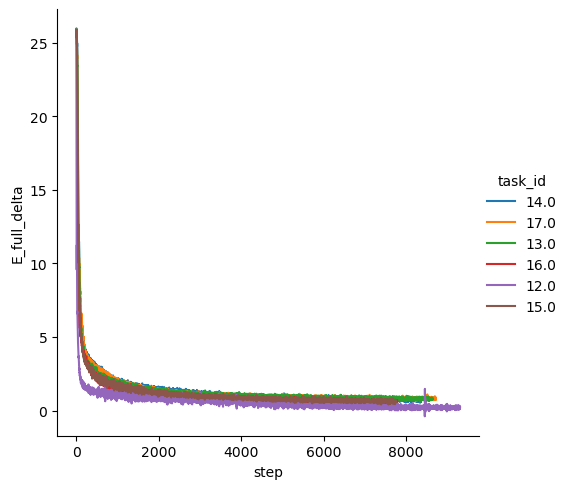

In [7]:
sns.relplot(
    df.query("task_id >= 12")
    .pipe(column_to(str, "task_id")),
    x="step",
    y="E_full_delta",
    kind="line",
    hue="task_id",
   # style='task_id',
)#.set(yscale="log")

(array([2512., 2407., 2217., 2010., 1928., 1879., 1760., 1539., 1395.,
        1109.,  912.,  654.,  480.,  349.,  265.,  215.,  106.,   80.,
          51.,   14.]),
 array([-7.99994707, -7.69375753, -7.38756752, -7.08137798, -6.77518845,
        -6.46899843, -6.1628089 , -5.85661888, -5.55042934, -5.24423981,
        -4.93804979, -4.63186026, -4.32567024, -4.01948071, -3.71329117,
        -3.40710139, -3.10091162, -2.79472184, -2.48853207, -2.18234253,
        -1.87615275]),
 <BarContainer object of 20 artists>)

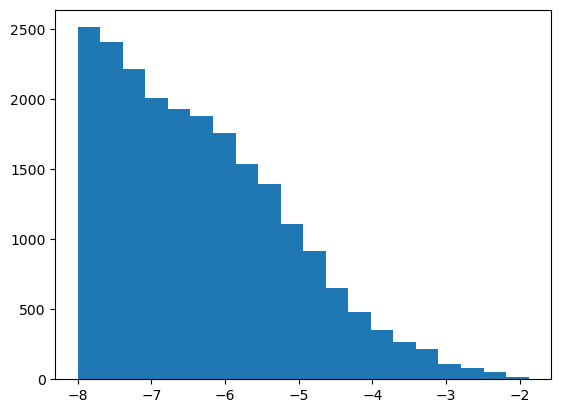

In [75]:
predicted_amplitudes = np.load(output_dir / "3" / "amplitudes_718.npy")
plt.hist(np.log10(predicted_amplitudes[(~np.isclose(predicted_amplitudes, 0))]), bins=20)

In [18]:
pred_delta = []
for i in range(1000):
    predictions = np.load(output_dir / "5" / f"predictions_{i}.npy")
    sorted_predictions = np.sort(predictions.flatten())
    pred_delta.append(sorted_predictions[-1] - sorted_predictions[-2])

In [ ]:
np.load(output_dir / "3" / f"predictions_{i}.npy")

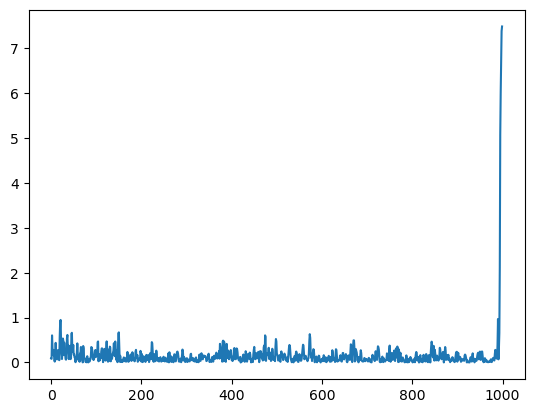

In [19]:
plt.plot(pred_delta)

(array([1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00,
        3.000e+00, 0.000e+00, 3.000e+00, 6.000e+00, 8.000e+00, 1.500e+01,
        4.700e+01, 3.370e+02, 4.423e+03, 2.373e+03, 1.460e+02, 3.100e+01,
        1.700e+01, 7.000e+00, 4.000e+00, 2.000e+00, 2.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([0.80911308, 0.89806393, 0.98701479, 1.07596564, 1.1649165 ,
        1.25386735, 1.34281821, 1.43176906, 1.52071992, 1.60967077,
        1.69862163, 1.78757248, 1.87652334, 1.96547419, 2.05442505,
        2.1433759 , 2.23232676, 2.32127761, 2.41022847, 2.49917932,
        2.58813018, 2.67708103, 2.76603189, 2.85498274, 2.9439336 ,
        3.03288445, 3.12183531, 3.21

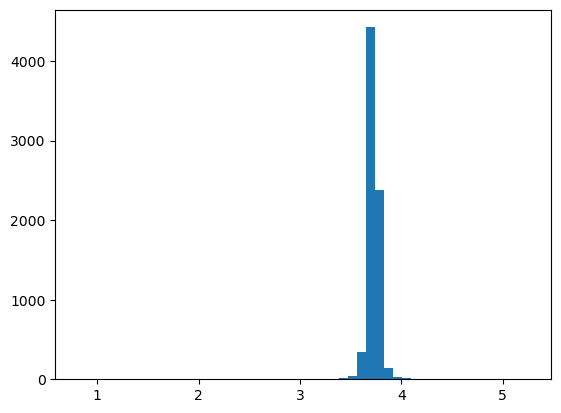

In [136]:
i = 300
log_E_loc = np.load(output_dir / "2" / f"log_E_loc_{i}.npy")
plt.hist(log_E_loc.real, bins=50)